In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data (1).csv to data (1).csv


In [3]:
df = pd.read_csv("data (1).csv")

In [4]:
df = df.drop(["id", "Unnamed: 32"], axis=1)

In [5]:
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

In [6]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
tree = DecisionTreeClassifier(random_state=42)

In [9]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
y_pred = tree.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [12]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[68  3]
 [ 3 40]]


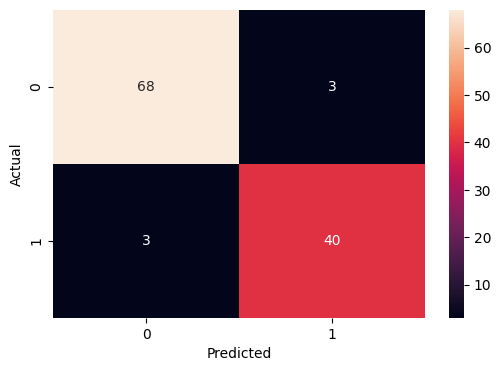

In [13]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



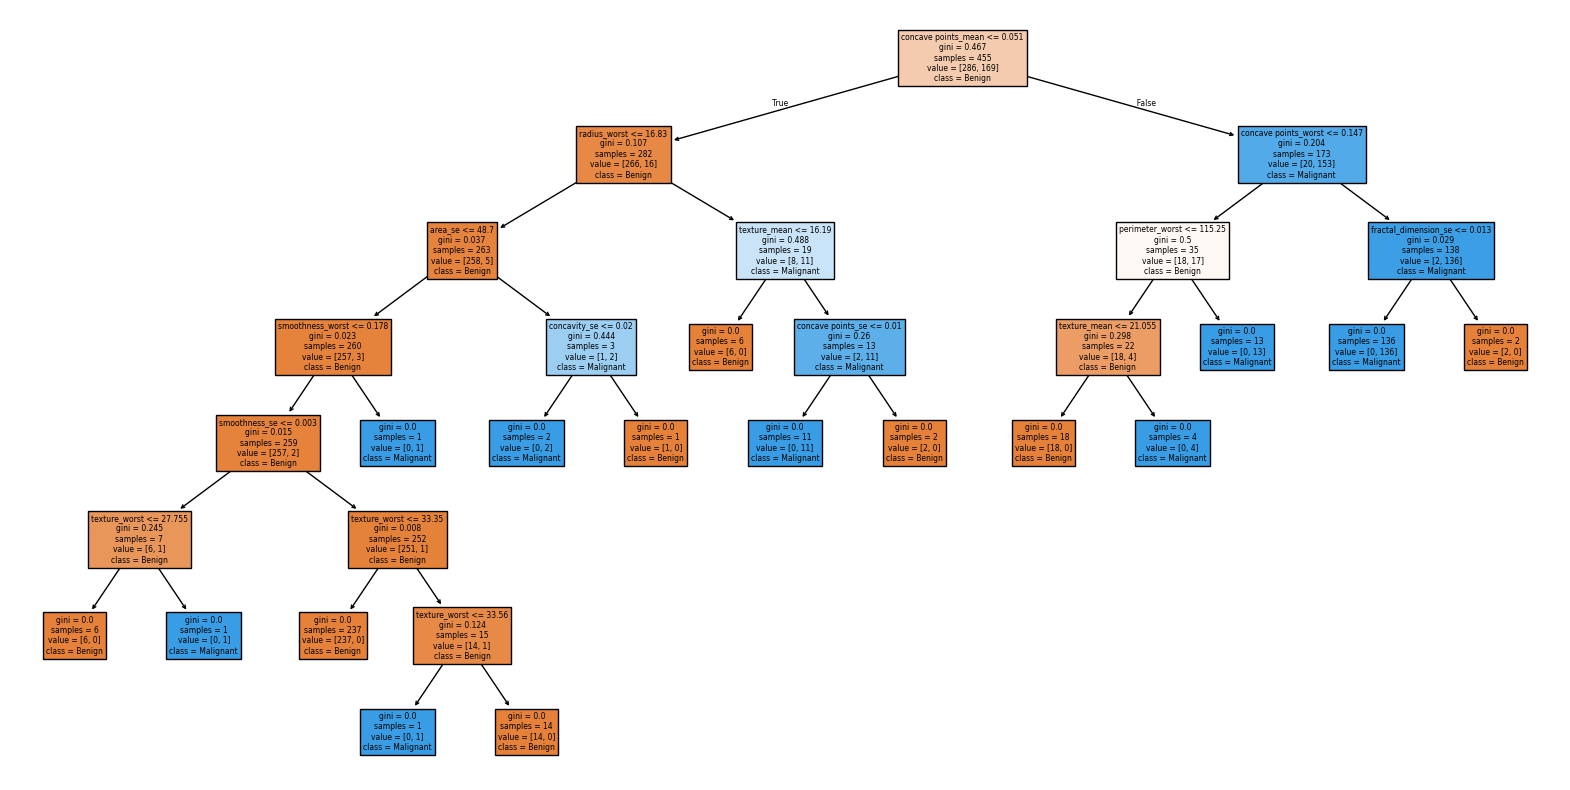

In [15]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Benign","Malignant"],
    filled=True
)

plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
7    concave points_mean    0.691420
27  concave points_worst    0.065651
1           texture_mean    0.058478
20          radius_worst    0.052299
22       perimeter_worst    0.051494
19  fractal_dimension_se    0.018554
21         texture_worst    0.017445
17     concave points_se    0.015931
13               area_se    0.011983
24      smoothness_worst    0.009233
